In [9]:
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from torchvision import utils

from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time

In [10]:
# the assessment provides tensors in a .pt file, not a torchvision dataset
bs_train = 128
bs_test  = 128

d = torch.load('mnist_custom.pt', map_location='cpu', weights_only=False)
for k, v in d.items():
    print(k, tuple(v.shape), v.dtype, 'min', float(v.min()), 'max', float(v.max()))

# the tutorial's transform did x*2-1 to map pixels into [-1, 1], which is what the
# diffusion process assumes. The .pt tensors are already in [0, 1], so we do that
# rescaling ourselves here.
train_images = d['train_images'] * 2 - 1
test_images  = d['test_images']  * 2 - 1

train_dataset = TensorDataset(train_images, d['train_labels'])
test_dataset  = TensorDataset(test_images,  d['test_labels'])

train_dataloader = DataLoader(train_dataset, batch_size=bs_train, shuffle=True,  num_workers=0, pin_memory=False)
test_dataloader  = DataLoader(test_dataset,  batch_size=bs_test,  shuffle=False, num_workers=0, pin_memory=False)

x, y = next(iter(train_dataloader))
print('batch:', x.shape, y.shape, 'range', float(x.min()), float(x.max()))

train_images (60000, 1, 20, 20) torch.float32 min 0.0 max 1.0
train_labels (60000,) torch.int64 min 0.0 max 9.0
test_images (10000, 1, 20, 20) torch.float32 min 0.0 max 1.0
test_labels (10000,) torch.int64 min 0.0 max 9.0
batch: torch.Size([128, 1, 20, 20]) torch.Size([128]) range -1.0 1.0


In [11]:
# --- tutorial cell: extract() and q_sample() are unchanged ---
import math

def extract(a, t, x_shape):
    """
    Extracts coefficients at specified timesteps, then reshapes to [batch_size, 1, 1, 1] for broadcasting purposes 
    (piecewise multiplication with the noise image)
    a: Tensor of shape (num_timesteps) (e.g. alpha_bar)
    t: Tensor of shape (batch_size) with timestep indices
    """    
    batch_size = t.shape[0]
    out = a.gather(-1, t).reshape(batch_size, *((1,) * (len(x_shape) - 1)))
    return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
timesteps = 1000
image_size = 20          # 20x20 for this dataset, the tutorial used 28
channels = 1

def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, timesteps)


def cosine_beta_schedule(timesteps, s=0.008):
    """
    Cosine schedule from Nichol & Dhariwal (2021), "Improved Denoising Diffusion
    Probabilistic Models". Instead of defining beta directly, it defines the
    cumulative product alpha_bar as a squared cosine:

        alpha_bar(t) = cos((t/T + s) / (1 + s) * pi/2)^2,   normalised so alpha_bar(0) = 1

    and recovers beta from the ratio of consecutive alpha_bar values.
    The small offset s = 0.008 stops beta from being too close to 0 at t = 0.
    betas are clipped at 0.999 so the process never becomes singular.
    """
    steps = timesteps + 1
    t = torch.linspace(0, timesteps, steps) / timesteps
    alphas_cumprod = torch.cos((t + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0, 0.999)


def set_schedule(name):
    """
    Reassigns the global betas / alphas / alpha_bars that q_sample and the
    sampling functions read. Done this way so q_sample and p_sample stay exactly
    as written in the tutorial instead of taking extra arguments.
    """
    global betas, alphas, alpha_bars
    if name == 'linear':
        betas = linear_beta_schedule(timesteps).to(device)
    elif name == 'cosine':
        betas = cosine_beta_schedule(timesteps).to(device)
    else:
        raise ValueError(f'unknown schedule: {name}')
    alphas = 1.0 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)
    return betas, alphas, alpha_bars


set_schedule('linear')   # start with the tutorial's schedule

def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0).to(device)
    sqrt_alpha_bar = torch.sqrt(extract(alpha_bars, t, x0.shape))
    sqrt_one_minus_alpha_bar = torch.sqrt(extract(1 - alpha_bars, t, x0.shape))
    return sqrt_alpha_bar * x0 + noise * sqrt_one_minus_alpha_bar

cuda


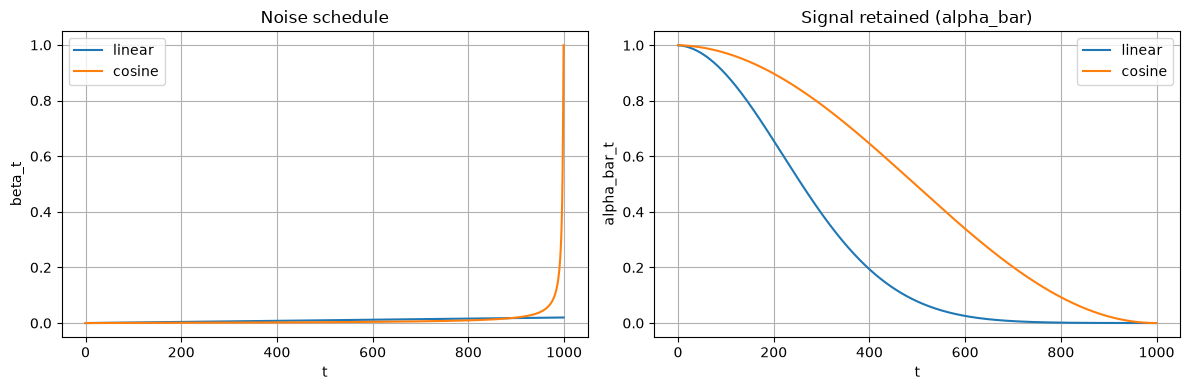

linear  alpha_bar at t=500: 0.0778   first t below 0.5:  259   below 0.01:  673
cosine  alpha_bar at t=500: 0.4923   first t below 0.5:  496   below 0.01:  935


In [12]:
# compare the two schedules before training anything: this is the whole reason
# we expect a difference, so it is worth seeing it
betas_lin = linear_beta_schedule(timesteps)
betas_cos = cosine_beta_schedule(timesteps)
abar_lin  = torch.cumprod(1 - betas_lin, dim=0)
abar_cos  = torch.cumprod(1 - betas_cos, dim=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(betas_lin.numpy(), label='linear')
axes[0].plot(betas_cos.numpy(), label='cosine')
axes[0].set_xlabel('t'); axes[0].set_ylabel('beta_t'); axes[0].set_title('Noise schedule')
axes[0].legend(); axes[0].grid()

axes[1].plot(abar_lin.numpy(), label='linear')
axes[1].plot(abar_cos.numpy(), label='cosine')
axes[1].set_xlabel('t'); axes[1].set_ylabel('alpha_bar_t')
axes[1].set_title('Signal retained (alpha_bar)')
axes[1].legend(); axes[1].grid()

plt.tight_layout()
plt.savefig('fig_schedules.png', dpi=150, bbox_inches='tight')
plt.show()

for name, ab in [('linear', abar_lin), ('cosine', abar_cos)]:
    # the step at which only 50% / 10% / 1% of the original signal is left
    print(f'{name:7s} alpha_bar at t=500: {ab[500]:.4f}   '
          f'first t below 0.5: {(ab < 0.5).nonzero()[0].item():4d}   '
          f'below 0.01: {(ab < 0.01).nonzero()[0].item():4d}')

In [13]:
channels = 1 # for MNIST

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)


class UNet_cond(nn.Module):
    def __init__(self, ch=32, n_classes=10):
        super().__init__()
        # encoder
        self.enc1 = ConvBlock(channels, ch)
        self.enc2 = ConvBlock(ch, ch*2)
        # bottleneck
        self.bot = ConvBlock(ch*2, ch*2)
        # decoder
        self.dec2 = ConvBlock(ch*2 + ch*2, ch)
        self.dec1 = ConvBlock(ch + ch, ch)
        # final
        self.final = nn.Conv2d(ch, channels, 1)

        # timestep embedding
        self.time_mlp = nn.Sequential(
            nn.Linear(1, ch),
            nn.ReLU(),
            nn.Linear(ch, ch)
        )

        # class embedding
        self.class_emb =  nn.Embedding(n_classes,ch)

        # projections to match channel dims
        self.to_e1 = nn.Conv2d(ch, ch, 1)
        self.to_e2 = nn.Conv2d(ch, ch*2, 1)
        self.to_b  = nn.Conv2d(ch, ch*2, 1)
        self.to_d2 = nn.Conv2d(ch, ch, 1)
        self.to_d1 = nn.Conv2d(ch, ch, 1)

        self.pool = nn.AvgPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x, t, y):        
        t = t.float().unsqueeze(-1) / timesteps
        t_emb = self.time_mlp(t).unsqueeze(-1).unsqueeze(-1)  

        y_emb = self.class_emb(y).unsqueeze(-1).unsqueeze(-1)

        cond_emb = t_emb + y_emb

        e1 = self.enc1(x) + self.to_e1(cond_emb)
        e2 = self.enc2(self.pool(e1)) + self.to_e2(cond_emb)

        b = self.bot(self.pool(e2)) + self.to_b(cond_emb)

        d2 = self.upsample(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2) + self.to_d2(cond_emb)

        d1 = self.upsample(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1) + self.to_d1(cond_emb)

        return self.final(d1)


# shape check: 20 -> 10 -> 5 -> 10 -> 20, no architecture change needed for 20x20
m_test = UNet_cond().to(device)
xb, yb = next(iter(train_dataloader))
out = m_test(xb[:4].to(device), torch.tensor([0, 10, 500, 999]).to(device), yb[:4].to(device))
print('input :', tuple(xb[:4].shape))
print('output:', tuple(out.shape))
print('params:', sum(p.numel() for p in m_test.parameters()))
del m_test

input : (4, 1, 20, 20)
output: (4, 1, 20, 20)
params: 221569


In [14]:
def train_ddpm(schedule_name, epochs=150, lr=2e-4, n_channels_unet=32, n_class=10, seed=0):
    """
    Trains one conditional DDPM. The loop body is the tutorial's training loop
    unchanged; it is wrapped in a function so both schedules are trained with
    identical settings, seeds and data order, which is what makes the comparison
    fair. Returns the model and the per-epoch mean loss.
    """
    set_schedule(schedule_name)      # MUST come first: q_sample reads the globals
    print(f'--- training with the {schedule_name} schedule')

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    model = UNet_cond(ch=n_channels_unet, n_classes=n_class).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    epoch_losses = []
    runtime = time.time()
    for epoch in range(epochs):
        model.train()
        running, n_batch = 0.0, 0
        pbar = tqdm(iterable=train_dataloader, unit="batch",
                    desc=f'training epoch {epoch+1}/{epochs}', colour='GREEN')
        for imgs, labels in pbar:
            imgs = imgs.to(device)
            labels = labels.to(device)

            batch_size = imgs.shape[0]
            t = torch.randint(0, timesteps, (batch_size,), device=device).long()
            noise = torch.randn_like(imgs)
            x_t = q_sample(imgs, t, noise=noise)

            pred_noise = model(x_t, t, labels)
            loss = loss_fn(pred_noise, noise)

            opt.zero_grad()
            loss.backward()
            opt.step()

            running += loss.item()
            n_batch += 1
            pbar.set_postfix(loss=loss.item())
        pbar.close()
        epoch_losses.append(running / n_batch)

    train_time = time.time() - runtime
    print(f'Training time: {train_time:.2f} seconds   final epoch loss: {epoch_losses[-1]:.5f}')
    return model, epoch_losses, train_time

In [15]:
# train the two models with identical settings, only the schedule differs
model_linear, losses_linear, time_linear = train_ddpm('linear', epochs=150)
torch.save(model_linear.state_dict(), 'ddpm_linear.pth')
with open('losses_linear.pkl', 'wb') as f:
    pickle.dump({'losses': losses_linear, 'train_time': time_linear}, f)
print('saved ddpm_linear.pth and losses_linear.pkl')

model_cosine, losses_cosine, time_cosine = train_ddpm('cosine', epochs=150)
torch.save(model_cosine.state_dict(), 'ddpm_cosine.pth')
with open('losses_cosine.pkl', 'wb') as f:
    pickle.dump({'losses': losses_cosine, 'train_time': time_cosine}, f)
print('saved ddpm_cosine.pth and losses_cosine.pkl')

print(f'\nlinear: {time_linear:.1f}s, final loss {losses_linear[-1]:.5f}')
print(f'cosine: {time_cosine:.1f}s, final loss {losses_cosine[-1]:.5f}')

--- training with the linear schedule


training epoch 150/150: 100%|██████████| 469/469 [00:08<00:00, 55.80batch/s, loss=0.0285]


Training time: 1257.39 seconds   final epoch loss: 0.02804
saved ddpm_linear.pth and losses_linear.pkl
--- training with the cosine schedule


training epoch 150/150: 100%|██████████| 469/469 [00:18<00:00, 25.66batch/s, loss=0.05]  


Training time: 2245.52 seconds   final epoch loss: 0.04910
saved ddpm_cosine.pth and losses_cosine.pkl

linear: 1257.4s, final loss 0.02804
cosine: 2245.5s, final loss 0.04910


In [17]:
@torch.no_grad()
def p_sample_cDDPM(model, x_t, t_index, y):
    """
    Single reverse step
    t_index: scalar int (0..T-1) (all elements in batch have same t)
    """
    t = torch.full((x_t.shape[0],), t_index, device=x_t.device, dtype=torch.long)
    beta = extract(betas, t, x_t.shape)
    alpha = extract(alphas, t, x_t.shape)
    alpha_bar = extract(alpha_bars, t, x_t.shape)
    sigma = torch.sqrt(beta)
    
    pred_noise = model(x_t, t, y)

    if t_index == 0:
        z = 0
    else:
        z = torch.randn_like(x_t)
    
    x_tm1 = 1.0 / alpha.sqrt() * (x_t - beta / ( (1 - alpha_bar).sqrt() ) * pred_noise) + sigma*z
    
    return x_tm1


@torch.no_grad()
def p_sample_loop_cDDPM(model, y, seed=1337):
    model.eval()
    torch.manual_seed(seed)
    n_samples = y.shape[0]
    x = torch.randn(n_samples, channels, image_size, image_size).to(device)  # x_T ~ N(0,I)
    pbar = tqdm(reversed(range(0, timesteps)), desc='Sampling loop', total=timesteps, colour='BLUE')
    for t in pbar:
        x = p_sample_cDDPM(model, x, t , y)
    return x.clamp(-1,1)

Sampling loop: 100%|██████████| 1000/1000 [00:10<00:00, 99.35it/s]


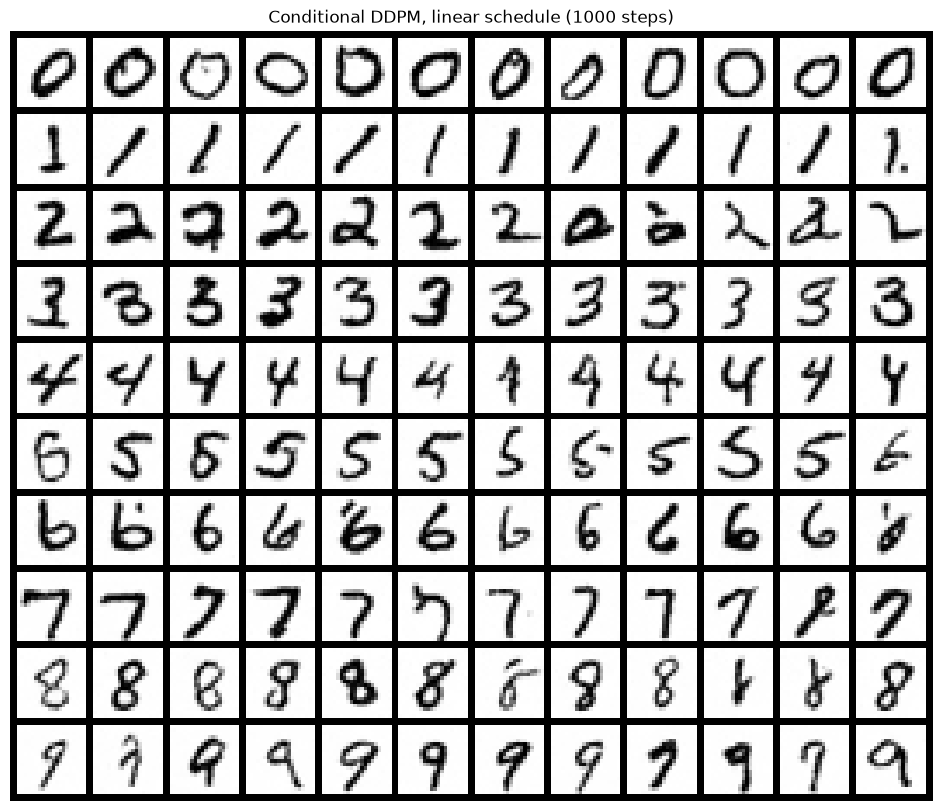

Sampling loop: 100%|██████████| 1000/1000 [00:10<00:00, 99.44it/s]


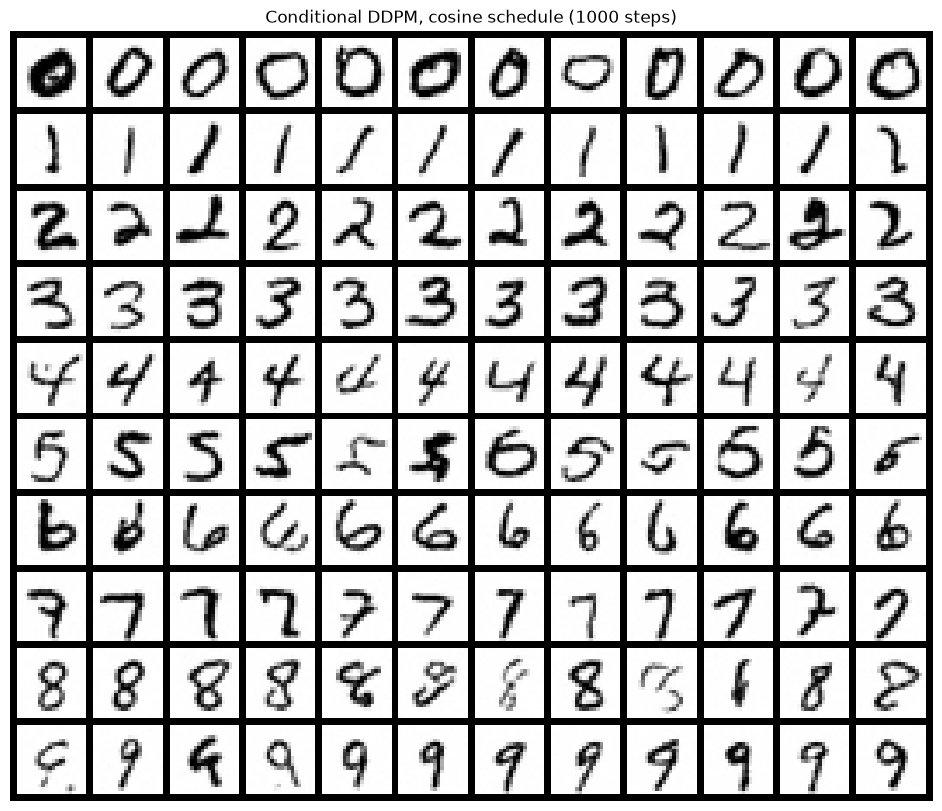

saved samples_full.pkl


In [18]:
sample_per_class = 12     # the brief requires 12 samples per digit (120 images per model)
labels = torch.arange(0,10).unsqueeze(1).repeat(1,sample_per_class).view(-1).to(device)

grids = {}
for name, model in [('linear', model_linear), ('cosine', model_cosine)]:
    set_schedule(na@torch.no_grad()
def p_sample_loop_strided(model, y, n_steps, seed=1337):
    """
    DDPM sampling using only a subset of the 1000 training timesteps.

    The model was trained on all 1000 steps, but at generation time we walk a
    shorter evenly-spaced subsequence of them (e.g. 25 steps). The update is the
    SAME formula as p_sample_cDDPM; the only change is that alpha and beta are
    recomputed for the bigger jumps we are now taking:

        alpha_i = alpha_bar[t_cur] / alpha_bar[t_prev],   beta_i = 1 - alpha_i

    The model is still called with the ORIGINAL timestep index t_cur, because
    that is the value its time embedding was trained on.

    This function is not part of Tutorial 9.3. It is needed because the tutorial's
    sampling loop always runs the full 1000 steps, so it cannot test a hypothesis
    about using fewer steps. The alternative - retraining a model for every step
    count - would mean a dozen training runs.
    """
    model.eval()
    torch.manual_seed(seed)
    x = torch.randn(y.shape[0], channels, image_size, image_size).to(device)

    # evenly spaced subsequence of timesteps, walked from T-1 down to 0
    seq = torch.linspace(0, timesteps - 1, n_steps).long().flip(0).tolist()

    for i, t_cur in enumerate(seq):
        t_batch = torch.full((x.shape[0],), t_cur, device=device, dtype=torch.long)

        alpha_bar_t = alpha_bars[t_cur]
        if i + 1 < len(seq):
            alpha_bar_prev = alpha_bars[seq[i + 1]]
            z = torch.randn_like(x)
        else:
            alpha_bar_prev = torch.tensor(1.0, device=device)   # clean image at the end
            z = 0

        alpha_i = alpha_bar_t / alpha_bar_prev
        beta_i  = 1 - alpha_i

        pred_noise = model(x, t_batch, y)
        x = 1.0 / alpha_i.sqrt() * (x - beta_i / (1 - alpha_bar_t).sqrt() * pred_noise) \
            + beta_i.sqrt() * z

    return x.clamp(-1, 1)me)        # MUST match the schedule the model was trained with
    samples = p_sample_loop_cDDPM(model, labels)
    samples = (samples + 1.0) / 2.0
    grids[name] = samples.cpu()

    grid = utils.make_grid(samples, nrow=sample_per_class)
    plt.figure(figsize=(12,10))
    plt.axis('off')
    plt.imshow(grid.permute(1,2,0).cpu())
    plt.title(f'Conditional DDPM, {name} schedule (1000 steps)')
    plt.savefig(f'grid_{name}_1000.png', dpi=150, bbox_inches='tight')
    plt.show()

with open('samples_full.pkl', 'wb') as f:
    pickle.dump({'labels': labels.cpu(), 'grids': grids}, f)
print('saved samples_full.pkl')

In [21]:
@torch.no_grad()
def p_sample_loop_strided(model, y, n_steps, seed=1337):
    """
    DDPM sampling using only a subset of the 1000 training timesteps.

    The model was trained on all 1000 steps; at generation time we walk a shorter
    evenly-spaced subsequence of them. The model is still called with the ORIGINAL
    timestep index, because that is what its time embedding was trained on.

    Unlike the tutorial's p_sample_cDDPM, this uses the posterior form of the
    reverse step: the predicted noise is first converted into a predicted clean
    image x0, which is clamped to [-1, 1] before taking the step. That clamp is
    essential here. With large jumps the coefficient 1/sqrt(alpha) becomes huge
    (over 3000x for the cosine schedule at 10 steps, because its alpha_bar decays
    to ~1e-9 at t=999), so any error in the predicted noise is amplified until the
    image saturates. Clamping x0 bounds that amplification.
    Both forms are algebraically the same reverse step when the jumps are small.

    This function is not part of Tutorial 9.3. It is needed because the tutorial's
    sampling loop always runs the full 1000 steps, so it cannot test a hypothesis
    about using fewer steps.
    """
    model.eval()
    torch.manual_seed(seed)
    x = torch.randn(y.shape[0], channels, image_size, image_size).to(device)

    seq = torch.linspace(0, timesteps - 1, n_steps).long().flip(0).tolist()
    one = torch.tensor(1.0, device=device)

    for i, t_cur in enumerate(seq):
        t_batch = torch.full((x.shape[0],), t_cur, device=device, dtype=torch.long)

        ab_t    = alpha_bars[t_cur]
        ab_prev = alpha_bars[seq[i + 1]] if i + 1 < len(seq) else one
        last    = (i + 1 == len(seq))

        pred_noise = model(x, t_batch, y)

        # predicted clean image, clamped to the valid pixel range
        x0 = (x - (1 - ab_t).sqrt() * pred_noise) / ab_t.sqrt()
        x0 = x0.clamp(-1, 1)

        if last:
            x = x0
        else:
            # posterior q(x_prev | x_t, x0) of the respaced chain
            alpha_i    = ab_t / ab_prev
            beta_tilde = (1 - ab_prev) / (1 - ab_t) * (1 - alpha_i)
            mean = ((ab_prev.sqrt() * (1 - alpha_i) / (1 - ab_t)) * x0
                    + (alpha_i.sqrt() * (1 - ab_prev) / (1 - ab_t)) * x)
            x = mean + beta_tilde.sqrt() * torch.randn_like(x)

    return x.clamp(-1, 1)

linear 1000 steps done
linear  500 steps done
linear  250 steps done
linear  100 steps done
linear   50 steps done
linear   25 steps done
linear   10 steps done
cosine 1000 steps done
cosine  500 steps done
cosine  250 steps done
cosine  100 steps done
cosine   50 steps done
cosine   25 steps done
cosine   10 steps done
saved samples_sweep.pkl


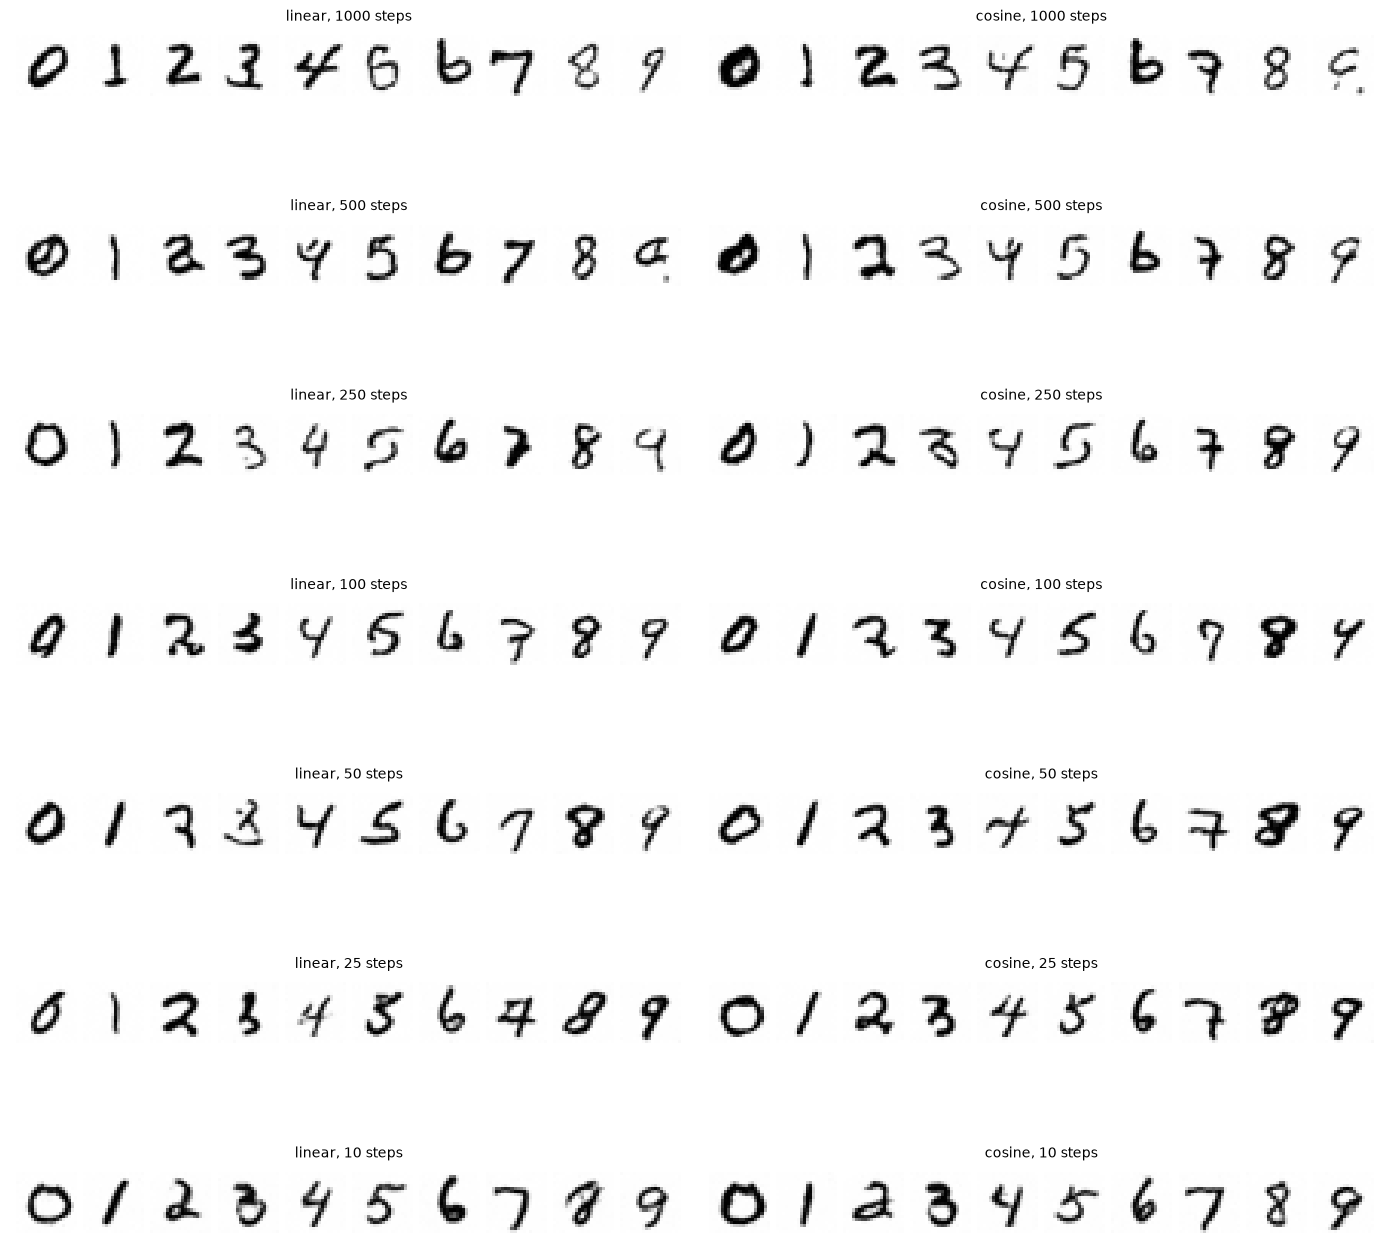

In [22]:
step_counts = [1000, 500, 250, 100, 50, 25, 10]

sweep = {}
for name, model in [('linear', model_linear), ('cosine', model_cosine)]:
    set_schedule(name)
    for n in step_counts:
        x = p_sample_loop_strided(model, labels, n)
        sweep[(name, n)] = ((x + 1.0) / 2.0).cpu()
        print(f'{name:6s} {n:4d} steps done')

with open('samples_sweep.pkl', 'wb') as f:
    pickle.dump({'labels': labels.cpu(), 'sweep': sweep, 'step_counts': step_counts}, f)
print('saved samples_sweep.pkl')


# one sample per digit at each step count, so the two schedules can be compared
# row by row as the step budget shrinks
fig, axes = plt.subplots(len(step_counts), 2, figsize=(14, 2.0 * len(step_counts)))
for r, n in enumerate(step_counts):
    for c, name in enumerate(['linear', 'cosine']):
        row_imgs = torch.stack([sweep[(name, n)][d * sample_per_class] for d in range(10)])
        grid = utils.make_grid(row_imgs, nrow=10, pad_value=1)
        axes[r, c].imshow(grid.permute(1, 2, 0))
        axes[r, c].axis('off')
        axes[r, c].set_title(f'{name}, {n} steps', fontsize=10)
plt.tight_layout()
plt.savefig('fig_step_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# A standalone digit classifier used only as a judge: trained on real images,
# never on generated ones. Not part of Tutorial 9.3; it turns the visual
# comparison above into a number.
from torch.utils.data import TensorDataset, DataLoader

class DigitClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super(DigitClassifier, self).__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(1,  16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Flatten(),                      # 64 * 3 * 3 = 576
        )
        self.head = nn.Sequential(
            nn.Linear(576, 128), nn.ReLU(),
            nn.Linear(128, num_classes),
        )
    def forward(self, x):
        return self.head(self.backbone(x))


torch.manual_seed(0)

# the classifier works on [0, 1] images, which is what the generated samples
# were converted back to, so we use the raw .pt tensors here (not the *2-1 ones)
clf_train_loader = DataLoader(TensorDataset(d['train_images'], d['train_labels']),
                              batch_size=256, shuffle=True,  num_workers=0)
clf_test_loader  = DataLoader(TensorDataset(d['test_images'],  d['test_labels']),
                              batch_size=1000, shuffle=False, num_workers=0)

clf = DigitClassifier().to(device)
clf_opt = torch.optim.AdamW(clf.parameters(), lr=1e-3)

for epoch in range(5):
    clf.train()
    for xb, yb in clf_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        clf_opt.zero_grad()
        loss = F.cross_entropy(clf(xb), yb)
        loss.backward()
        clf_opt.step()
    clf.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in clf_test_loader:
            xb, yb = xb.to(device), yb.to(device)
            correct += (clf(xb).argmax(1) == yb).sum().item()
            total   += yb.shape[0]
    print(f'epoch {epoch+1}: real test accuracy {correct/total:.4f}')

torch.save(clf.state_dict(), 'digit_classifier.pth')
print('saved digit_classifier.pth')

epoch 1: real test accuracy 0.9149
epoch 2: real test accuracy 0.9482
epoch 3: real test accuracy 0.9651
epoch 4: real test accuracy 0.9680
epoch 5: real test accuracy 0.9768
saved digit_classifier.pth


linear 1000:0.933  500:0.933  250:0.933  100:0.958  50:0.950  25:0.950  10:0.992
cosine 1000:0.967  500:0.950  250:0.967  100:0.933  50:0.975  25:0.967  10:0.992


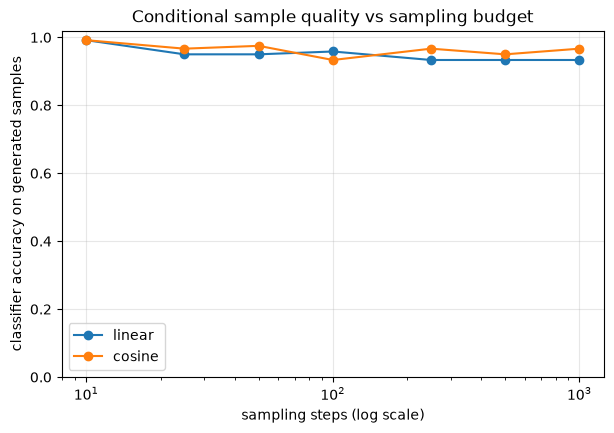

In [24]:
# does the classifier still read each generated sample as the digit it was
# conditioned on? 120 samples per setting.
clf.eval()
results = {}
for name in ['linear', 'cosine']:
    accs = []
    for n in step_counts:
        imgs = sweep[(name, n)].to(device)
        with torch.no_grad():
            pred = clf(imgs).argmax(1).cpu()
        accs.append((pred == labels.cpu()).float().mean().item())
    results[name] = accs
    print(f'{name:6s} ' + '  '.join(f'{n}:{a:.3f}' for n, a in zip(step_counts, accs)))

with open('results_accuracy.pkl', 'wb') as f:
    pickle.dump({'step_counts': step_counts, 'results': results}, f)

plt.figure(figsize=(7, 4.5))
for name in ['linear', 'cosine']:
    plt.plot(step_counts, results[name], 'o-', label=name)
plt.xscale('log')
plt.xlabel('sampling steps (log scale)')
plt.ylabel('classifier accuracy on generated samples')
plt.title('Conditional sample quality vs sampling budget')
plt.ylim(0, 1.02)
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('fig_accuracy_vs_steps.png', dpi=150, bbox_inches='tight')
plt.show()

real data reference: 0.3664

linear 1000:0.363  500:0.362  250:0.358  100:0.361  50:0.359  25:0.352  10:0.331
cosine 1000:0.369  500:0.367  250:0.368  100:0.365  50:0.363  25:0.357  10:0.347


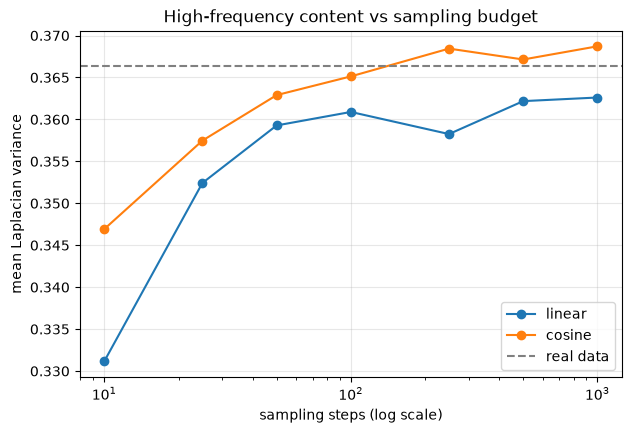

In [25]:
# The classifier above measures whether the conditioning survived, not image
# quality. The visible failure at low step counts is speckle noise, so we measure
# high-frequency energy directly and compare against real data as the reference.
def laplacian_variance(images):
    kernel = torch.tensor([[0.,  1., 0.],
                           [1., -4., 1.],
                           [0.,  1., 0.]]).view(1, 1, 3, 3)
    resp = F.conv2d(images, kernel, padding=1)
    return resp.view(images.shape[0], -1).var(dim=1)


real_lv = laplacian_variance(d['test_images'][:1000]).mean().item()
print(f'real data reference: {real_lv:.4f}\n')

lv_results = {}
for name in ['linear', 'cosine']:
    vals = [laplacian_variance(sweep[(name, n)]).mean().item() for n in step_counts]
    lv_results[name] = vals
    print(f'{name:6s} ' + '  '.join(f'{n}:{v:.3f}' for n, v in zip(step_counts, vals)))

with open('results_sharpness.pkl', 'wb') as f:
    pickle.dump({'step_counts': step_counts, 'lv': lv_results, 'real': real_lv}, f)

plt.figure(figsize=(7, 4.5))
for name in ['linear', 'cosine']:
    plt.plot(step_counts, lv_results[name], 'o-', label=name)
plt.axhline(real_lv, color='grey', linestyle='--', label='real data')
plt.xscale('log')
plt.xlabel('sampling steps (log scale)')
plt.ylabel('mean Laplacian variance')
plt.title('High-frequency content vs sampling budget')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('fig_sharpness_vs_steps.png', dpi=150, bbox_inches='tight')
plt.show()